In [5]:
import numpy as np
import torchvision
import matplotlib as mpl
import matplotlib.pyplot as plt

from scipy.stats import norm, gaussian_kde
from pylops.utils.metrics import snr

import torch, deepwave

def forward_propagator(
    vp,
    multi_source=True,
    total_sources=64,
    selected_sources=16,
    freq=4,
    nt=2000,
    dt=0.004,
    dz=6.25,
    dx=25,
    device=None,
    source_locations=None,
    receiver_locations=None,
    return_src_info=False,
    seed=None,
):
    """
    Forward modeling using Deepwave for either simultaneous or individual source experiments.

    Parameters
    -----------
    vp : Tensor
        Velocity model (C, H, W) or (1, C, H, W)
    multi_source : bool
        Whether to use simultaneous-source FWI.
    total_sources : int
        Total source positions available across the model.
    selected_sources : int
        Number of sources to activate per shot in simultaneous case.
    freq : float
        Frequency of source wavelet.
    nt : int
        Number of time steps.
    dt : float
        Time step (s).
    dx, dz : float
        Grid spacing in x and z.
    return_src_info : bool
        If True, return source/receiver info (for FWI loop).

    Returns
    --------
    data : Tensor
        Simulated seismic data.
    """
    if device is None:
        device = vp.device

    num_dims = 2
    nx = vp.shape[-1]
    num_shots = 1 if multi_source else total_sources
    num_sources_per_shot = selected_sources if multi_source else 1
    num_receivers_per_shot = nx

    # Generate default source/receiver positions
    if source_locations is None or receiver_locations is None:
        if seed is not None:
            torch.manual_seed(seed)
            np.random.seed(seed)

        x_src = dx
        y_positions = torch.linspace(0, (nx - 1) * dx, total_sources)

        if multi_source:
            sampled_idx = np.random.choice(total_sources, size=selected_sources, replace=False)
            y_srcs = y_positions[sampled_idx]
            source_locations = torch.zeros(num_shots, selected_sources, num_dims)
            source_locations[0, :, 0] = x_src
            source_locations[0, :, 1] = y_srcs
        else:
            source_locations = torch.zeros(num_shots, 1, num_dims)
            source_locations[:, 0, 0] = x_src
            source_locations[:, 0, 1] = y_positions[:num_shots]

        receiver_locations = torch.zeros(num_shots, num_receivers_per_shot, num_dims)
        receiver_locations[:, :, 0] = dx
        receiver_locations[:, :, 1] = torch.arange(num_receivers_per_shot) * dx
        
        # Divide by dx and dz to convert to grid units
        source_locations[:, :, 0] /= dz  # z-direction (usually 0 index)
        source_locations[:, :, 1] /= dx  # x-direction (usually 1 index)
        receiver_locations[:, :, 0] /= dz
        receiver_locations[:, :, 1] /= dx

    # Generate source amplitudes
    wavelet = deepwave.wavelets.ricker(freq, nt, dt, 1 / freq).to(device)
    source_amplitudes = wavelet.repeat(num_shots, num_sources_per_shot, 1)

    # Run Deepwave
    data = deepwave.scalar(
        vp,
        grid_spacing=[dz, dx],
        dt=dt,
        source_amplitudes=source_amplitudes.to(device),
        source_locations=source_locations.to(device),
        receiver_locations=receiver_locations.to(device),
        accuracy=8,
        pml_freq=freq,
        pml_width=[0, 13, 13, 10],
    )[-1]

    if return_src_info:
        return data, source_amplitudes, source_locations, receiver_locations
    else:
        return data

def show_realizations(reals, subregion, xtrue=None, vlims=None, extent=None,
                      nreals=6, ncols=3, figsize=(15, 10),
                      inset=[0.6, 0.04, 0.36, 0.36],
                      cmap='rainbow', xlabel=None, ylabel=None,
                      title=None, cbarlabel=None):
    """Display multiple realizations with optional close-up insets.

    This function visualizes a set of realizations in a grid layout with
    optional zoomed-in insets highlighting a specified subregion. Each subplot can
    display additional information such as the signal-to-noise ratio (SNR) if the
    true model is also provided.

    Parameters
    ----------
    reals : ndarray
        3D array of shape (nreals, height, width) containing the realizations to be displayed.
    subregion : tuple
        Four-element tuple specifying the subregion for zoomed-in insets as (x1, x2, y1, y2).
    xtrue : ndarray, optional
        Reference solution for calculating SNR. If provided, SNR values are included
        in subplot titles. Default is None.
    vlims : tuple, optional
        Tuple specifying the color scale limits as (vmin, vmax). If None,
        inferred from `reals`. Default is None.
    extent : tuple, optional
        Tuple specifying the spatial extent of the images as (xmin, xmax, ymin, ymax).
        Default is None.
    nreals : int, optional
        Number of realizations to display. Default is 6.
    ncols : int, optional
        Number of columns in the grid layout. Default is 3.
    figsize : tuple, optional
        Tuple specifying the figure size. Default is (15, 10).
    inset : list, optional
        List defining the position and size of the inset axes
        as [x, y, width, height]. Default is [0.6, 0.04, 0.36, 0.36].
    cmap : str, optional
        Colormap used for the realizations. Default is 'rainbow'.
    xlabel : str, optional
        Label for the x-axis. Default is None.
    ylabel : str, optional
        Label for the y-axis. Default is None.
    title : str, optional
        Title for the entire figure. Default is None.
    cbarlabel : str, optional
        Label for the colorbar. Default is None.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The figure containing the grid of subplots.
    axs : ndarray
        Array of Axes objects corresponding to the subplots.

    """

    x1, x2, y1, y2 = subregion
    vmin, vmax = vlims if vlims is not None else (reals.min(), reals.max())

    fig, axs = plt.subplots(max(int(np.ceil(nreals // ncols)), 1), ncols, sharex=True, sharey=True, figsize=figsize)
    if title:
        fig.suptitle(title)
    axs = axs.ravel()
    ireals = np.arange(nreals)
    for i, k in enumerate(ireals):
        axi = axs[i].imshow(np.flipud(reals[i]), vmin=vmin, vmax=vmax,
                            cmap=cmap, extent=extent, origin='lower')
        if xtrue is None:
            axs[i].set_title(f'Posterior Sample {k}')
        else:
            axs[i].set_title(f'Posterior Sample {k} (SNR={snr(xtrue, reals[i]):.2f})')
        axs[i].axis('tight')
        axs[i].set_aspect('auto', 'datalim')

        axins = axs[i].inset_axes(inset, xlim=(x1, x2), ylim=(y1, y2),
                                  xticklabels=[], yticklabels=[])
        axins.imshow(np.flipud(reals[i]), interpolation='sinc',
                     vmin=vmin, vmax=vmax, cmap=cmap,
                     extent=extent, origin='lower')

        axs[i].indicate_inset_zoom(axins, edgecolor="black")
        axins.axis('tight')
        axins.set_ylim(y2, y1)
        axins.set_xlim(x1, x2)

    if ylabel:
        for iax in range(0, max(int(np.ceil(nreals // ncols)), 1), ncols):
            axs[iax].set_ylabel(ylabel)
    if xlabel:
        for i in range(nreals - ncols, nreals):
            axs[i].set_xlabel(xlabel)
    cbar_ax = fig.add_axes([0.25, 0.0001 if (nreals // ncols) > 1 else -0.05, 0.5, 0.02])
    cbar = fig.colorbar(axi, cax=cbar_ax, orientation='horizontal')
    if cbarlabel is not None:
        cbar.set_label(cbarlabel)
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.1)

    return fig, axs


def show_realizationtraces(reals, means, stds,
                           ixs=None, stdcut=None,
                           nmaxis=201, true=None,
                           z=None, extent=None, labels=None,
                           colors='r', cmap="rainbow",
                           cmapstd="magma", cmappdf="plasma",
                           clippdf=0.1, vlims=None, xlabel=None,
                           ylabel=None, xlabelpdf=None,
                           title=None, figsize=(15, 13)):
    """Visualize realization traces and statistical summaries.

    This function generates a multi-panel visualization to compare multiple realizations at given
    horizontal locations: it either displays the marginal probability density functions at given
    horizontal locations alongside the mean and standard deviation 2D model and optional coverage ratio
    or multiple realizations for different cases alongside true 2D model and optional coverage ratio.

    Parameters
    ----------
    reals : list of ndarray or ndarray
        List of 3D arrays (nz, nx, nrealizations) representing the realizations for each case.
    means : list of ndarray or ndarray
        List of 2D arrays (nz, nx) representing the mean of each case.
    stds : list of ndarray or ndarray
        List of 2D arrays (nz, nx) representing the standard deviation of each case.
    ixs : list of ndarray or ndarray, optional
        List of indices of the x coordinates of the model to be displayed
    stdcut : float, optional
        Cutoff value for standard deviations; values below this are masked in the visualization.
    nmaxis : int, default=201
        Number of bins for marginal PDF visualization when only one case is provided.
    true : ndarray, optional
        2D array (nz, nx) representing the ground truth values to overlay on plots.
    z : ndarray, optional
        Array specifying the depth or vertical axis values. Default is `np.arange(nz)`.
    extent : tuple, optional
        Tuple specifying the bounding box (left, right, bottom, top) for spatial plots.
    labels : list of str, optional
        List of labels for the cases, used in legends and annotations.
    colors : str or list of str, optional
        Color(s) for the cases in the line plots. Should match the number of cases.
    cmap : str, optional
        Colormap for the mean plots.
    cmapstd : str, optional
        Colormap for overlaying standard deviations.
    cmappdf : str, optional
        Colormap for marginal PDF visualizations.
    clippdf : float, optional
        Clip to apply to pdf display.
    vlims : tuple, optional
        Tuple (vmin, vmax) specifying the value limits for the mean plots.
    xlabel : str, optional
        Label for the x-axis of the spatial plot.
    ylabel : str, optional
        Label for the y-axis of the spatial plot.
    xlabelpdf : str, optional
        Label for the x-axis of the PDF plots.
    title : str, optional
        Title for the entire figure.
    figsize : tuple, default=(15, 13)
        Size of the figure in inches.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The generated figure object.
    axes : tuple of matplotlib.axes._axes.Axes
        The axes objects for the subplots: (spatial, PDF1, PDF2, PDF3, PDF4).

    """

    if isinstance(means, list):
        ncases = len(reals)
    else:
        ncases = 1 
        reals = [reals, ]
        means = [means, ]
        stds = [stds, ]
    
    nz, nx = means[0].shape
    z = np.arange(nz) if z is None else z
    ixs = (nx // 5, 2 * nx // 5, 3 * nx // 5, 4 * nx // 5) if ixs is None else ixs
    vmin, vmax = vlims if vlims is not None else (means[0].min(), means[0].max())

    fig = plt.figure(figsize=figsize)
    fig.suptitle(title, fontweight='bold', fontsize=15)
    gs = mpl.gridspec.GridSpec(5, 4)
    ax0 = fig.add_subplot(gs[:2, :])
    ax1 = fig.add_subplot(gs[2:, 0])
    ax2 = fig.add_subplot(gs[2:, 1])
    ax3 = fig.add_subplot(gs[2:, 2])
    ax4 = fig.add_subplot(gs[2:, 3])

    if len(reals) > 1 and true is not None:
        ax0.imshow(true, vmin=vmin, vmax=vmax, extent=extent, cmap=cmap)
    elif len(reals) > 1:
        ax0.imshow(means[0], vmin=vmin, vmax=vmax, extent=extent, cmap=cmap)
    else:
        ax0.imshow(means[0], vmin=vmin, vmax=vmax, extent=extent, cmap=cmap)
        if stdcut is not None:
            stds_nan = stds[0].copy()
            stds_nan[stds_nan < stdcut] = np.nan
            ax0.imshow(stds_nan, vmin=0, vmax=stds[0].max(), extent=extent, cmap=cmapstd, alpha=0.6)

    if labels and true is not None:
        covratiotext = fr'Coverage ratio (2.58*$\sigma$ - 99%):' + '\n'
        for icase in range(ncases):
            covratio = 100 * np.sum((true > means[icase] - 2.58 * stds[icase]) &
                                    (true < means[icase] + 2.58 * stds[icase])) / true.size
            covratiotext += f'{labels[icase]}={covratio:.1f}\n'
        covratiotext = covratiotext[:-1]
        ax0.text(0.015, 0.95, covratiotext, va='top', bbox=dict(boxstyle='round', facecolor='white'),
                 transform=ax0.transAxes)

    ax0.axis('tight')
    ax0.set_xlabel(xlabel)
    ax0.set_ylabel(ylabel)

    for ix in ixs:
        if extent:
            ax0.axvline((extent[1] - extent[0]) * ix / nx + extent[0], color='k')
        else:
            ax0.axvline(ix, color='k')
    
    if ncases > 1:
        for ax, ix in zip((ax1, ax2, ax3, ax4), ixs):
            if true is not None:
                ax.plot(true[..., ix].T, z, 'k', lw=2, label='True')

            for icase in range(ncases):
                ax.plot(reals[icase][..., ix].T, z, colors[icase], lw=0.2)
                ax.plot(means[icase][:, ix], z, colors[icase], lw=2,
                        label=None if ncases == 1 or labels is None else labels[icase])
                ax.fill_betweenx(z, means[icase][:, ix] - 2 * stds[icase][:, ix],
                                 means[icase][:, ix] + 2 * stds[icase][:, ix], color=colors[icase], alpha=0.2)
            ax.invert_yaxis()
            ax.set_xlabel(xlabelpdf)
        ax1.set_ylabel(ylabel)
        if labels is not None:
            ax.legend()
        for ax in (ax2, ax3, ax4):
            ax.set_yticks([], [])
    else:
        maxis = np.linspace(vmin, vmax, nmaxis)
        mmarginals = []
        for ix in ixs:
            mmarginal = np.zeros((nz, nmaxis))
            for iz in range(nz):
                rv = norm(loc=means[0][iz, ix], scale=stds[0][iz, ix])
                mmarginal[iz] = rv.pdf(maxis)
            mmarginals.append(mmarginal)
        mmarginalsmax = np.nanmax(np.hstack(mmarginals))

        for i, (ax, ix) in enumerate(zip((ax1, ax2, ax3, ax4), ixs)):
            mmarginal = mmarginals[i]
            ax.imshow(mmarginal, cmap=cmappdf, extent=(vmin, vmax, z[-1], z[0]),
                      vmin=0, vmax=clippdf * mmarginalsmax)
            if true is not None:
                ax.plot(true[..., ix].T, z, '#00FF27', lw=2, label='True')
            ax.plot(means[0][:, ix], z, 'w', lw=2,
                    label=None if labels is None else labels[0])
            ax.axis('tight')
            ax.grid('on')
            ax.set_xlim(vmin, vmax)
            ax.set_xlabel(xlabelpdf)
        ax1.set_ylabel(ylabel)
        if labels is not None:
            ax4.legend()
        for ax in (ax2, ax3, ax4):
            ax.set_yticklabels([],)

    fig.tight_layout()
    return fig, (ax0, ax1, ax2, ax3, ax4)


def show_1dmarginals(reals, means, stds,
                     coords, stdcut=None,
                     nmaxis=201, true=None,
                     extent=None, labels=None,
                     colors='r', cmap="rainbow",
                     cmapstd="magma", vlims=None,
                     xlabel=None, ylabel=None,
                     xlabelpdf=None, title=None,
                     figsize=(15, 13)):
    """Visualize 1D marginal probability distributions at specified coordinates

    This function creates a multi-panel figure to display 1D marginal distributions
    of a set of realizations for different cases at custom points of interest, alongside
    the mean and standard deviation 2D model (or true model) and optional coverage ratio.

    Parameters
    ----------
    reals : ndarray or list of ndarray
        List of 3D arrays (nrealizations, nz, nx) representing the realizations.
    means : list of ndarray or ndarray
        List of 2D arrays (nz, nx) representing the mean of each case.
    stds : list of ndarray or ndarray
        List of 2D arrays (nz, nx) representing the standard deviation of each case.
    coords : list of tuples
        List of four coordinate pairs, with each tuple `(x, z)` specifying
        a location in the data array.
    stdcut : float, optional
        Threshold for standard deviations below which regions are masked
        on the main plot. Default is `None`.
    nmaxis : int, optional
        Number of bins for KDE evaluation. Default is `201`.
    true : ndarray, optional
        Ground truth array for comparison. Shape `(height, width)`. Default is `None`.
    extent : tuple, optional
        Spatial extent of the data in the format `(xmin, xmax, ymin, ymax)`. Default is `None`.
    labels : list of str, optional
        Labels for each case in `reals`. Default is `None`.
    colors : str or list of str, optional
        Color(s) used for plotting the KDEs. Default is `'r'`.
    cmap : str, optional
        Colormap used for the mean field visualization. Default is `"rainbow"`.
    cmapstd : str, optional
        Colormap used for the standard deviation overlay. Default is `"magma"`.
    vlims : tuple of float, optional
        Value limits `(vmin, vmax)` for the colormap. Defaults to the range of `means`.
    xlabel : str, optional
        Label for the x-axis of the main plot. Default is `None`.
    ylabel : str, optional
        Label for the y-axis of the main plot. Default is `None`.
    xlabelpdf : str, optional
        Label for the x-axis of the marginal distribution plots. Default is `None`.
    title : str, optional
        Title for the figure. Default is `None`.
    figsize : tuple of float, optional
        Size of the figure in inches `(width, height)`. Default is `(15, 13)`.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure object.
    axes : tuple
        Tuple of axes objects for the main plot and the marginal distributions:
        `(ax0, ax1, ax2, ax3, ax4)`.

    """
    if len(coords) != 4:
        raise NotImplementedError('Provide 4 coordinates...')
    if isinstance(means, list):
        ncases = len(reals)
    else:
        ncases = 1
        reals = [reals, ]
        means = [means, ]
        stds = [stds, ]

    nz, nx = means[0].shape
    vmin, vmax = vlims if vlims is not None else (means[0].min(), means[0].max())

    fig = plt.figure(figsize=figsize)
    fig.suptitle(title, fontweight='bold', fontsize=15)
    gs = mpl.gridspec.GridSpec(4, 4)
    ax0 = fig.add_subplot(gs[:2, :])
    ax1 = fig.add_subplot(gs[2:3, :2])
    ax2 = fig.add_subplot(gs[2:3, 2:])
    ax3 = fig.add_subplot(gs[3:, :2])
    ax4 = fig.add_subplot(gs[3:, 2:])

    if len(reals) > 1 and true is not None:
        ax0.imshow(true, vmin=vmin, vmax=vmax, extent=extent, cmap=cmap)
    elif len(reals) > 1:
        ax0.imshow(means[0], vmin=vmin, vmax=vmax, extent=extent, cmap=cmap)
    else:
        ax0.imshow(means[0], vmin=vmin, vmax=vmax, extent=extent, cmap=cmap)
        if stdcut is not None:
            stds_nan = stds[0].copy()
            stds_nan[stds_nan < stdcut] = np.nan
            ax0.imshow(stds_nan, vmin=0, vmax=stds[0].max(), extent=extent, cmap=cmapstd, alpha=0.6)

    if labels and true is not None:
        covratiotext = fr'Coverage ratio (2.58*$\sigma$ - 99%):' + '\n'
        for icase in range(ncases):
            covratio = 100 * np.sum(
                (true > means[icase] - 2.58 * stds[icase]) & (true < means[icase] + 2.58 * stds[icase])) / true.size
            covratiotext += f'{labels[icase]}={covratio:.1f}\n'
        covratiotext = covratiotext[:-1]
        ax0.text(0.015, 0.95, covratiotext, va='top', bbox=dict(boxstyle='round', facecolor='white'),
                 transform=ax0.transAxes)
    ax0.axis('tight')
    ax0.set_xlabel(xlabel)
    ax0.set_ylabel(ylabel)

    for ipoint in range(len(coords)):
        if extent:
            ax0.scatter((extent[1] - extent[0]) * coords[ipoint][0] / nx + extent[0],
                        (extent[2] - extent[3]) * coords[ipoint][1] / nz + extent[3],
                        color='w', s=100)
            ax0.text((extent[1] - extent[0]) * coords[ipoint][0] / nx + extent[0],
                     (extent[2] - extent[3]) * coords[ipoint][1] / nz + extent[3], ipoint + 1,
                     fontsize=22, color='w')
        else:
            ax0.scatter(coords[ipoint][0], coords[ipoint][1], color='w', s=100)
            ax0.text(coords[ipoint][0], coords[ipoint][1], ipoint + 1, fontsize=22, color='w')

    for icoord, (ax, coord) in enumerate(zip((ax1, ax2, ax3, ax4), coords)):
        maxis = np.linspace(vmin, vmax, nmaxis)

        for icase in range(ncases):
            kernel = gaussian_kde(reals[icase][:, coord[1], coord[0]])
            kde = kernel(maxis)
            ax.plot(maxis, kde, colors[icase], lw=1,
                    label=None if labels is None else labels[icase])
            ax.fill_between(maxis, 0, kde, color=colors[icase], alpha=0.5)
            if true is not None:
                ax.axvline(true[coord[1], coord[0]], color='k')
        ax.set_yticks([], [])
        ax.set_title(f'Point {icoord +1}')

    for ax in (ax3, ax4):
        ax.set_xlabel(xlabelpdf)

    if labels is not None:
        ax.legend()

    fig.tight_layout()
    return fig, (ax0, ax1, ax2, ax3, ax4)


def show_2dmarginals(reals, means, stds,
                     coords, stdcut=None,
                     nmaxis=201, true=None,
                     extent=None, labels=None,
                     colors='r', cmap="rainbow",
                     cmapstd="magma", vlims=None,
                     xlabel=None, ylabel=None,
                     xlabelpdf=None, title=None,
                     figsize=(15, 13)):
    """Visualize 2D marginal distributions.

    This function creates a multi-panel figure to display 2D marginal distributions
    of variables, their mean values, standard deviations, and optional coverage ratios.
    It also supports plotting true values and custom points of interest.

    Parameters
    ----------
    reals : list or ndarray
        List of 3D arrays or a single 3D array of realizations to plot.
        The shape of each array should be `(n_samples, nz, nx)`.
    means : list or ndarray
        List of 2D arrays or a single 2D array of mean values corresponding to the realizations.
    stds : list or ndarray
        List of 2D arrays or a single 2D array of standard deviations.
    coords : list of tuple
        List of 4 coordinate pairs defining the points to be analyzed.
        Each coordinate pair should be structured as `((x1, y1), (x2, y2))`.
    stdcut : float, optional
        Threshold for standard deviation overlay. Values below this will be set to NaN.
    nmaxis : int, optional
        Number of points to use for the marginal axis. Default is 201.
    true : ndarray, optional
        2D array representing the true underlying field.
    extent : tuple, optional
        The extent of the plot in the form `(xmin, xmax, ymin, ymax)`.
    labels : list of str, optional
        Labels for different cases. Used in coverage ratio calculation.
    colors : str or list, optional
        Colors for contour lines. Default is `'r'`.
    cmap : str, optional
        Colormap for displaying the mean values. Default is `'rainbow'`.
    cmapstd : str, optional
        Colormap for displaying the standard deviation overlay. Default is `'magma'`.
    vlims : tuple, optional
        Value limits for the mean plot as `(vmin, vmax)`. Defaults to the range of `means`.
    xlabel : str, optional
        Label for the x-axis of the main plot.
    ylabel : str, optional
        Label for the y-axis of the main plot.
    xlabelpdf : str, optional
        Label for the x-axis of the marginal PDF plots.
    title : str, optional
        Title for the overall figure.
    figsize : tuple, optional
        Figure size as `(width, height)`. Default is `(15, 13)`.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure.
    axes : tuple of matplotlib.axes.Axes
        Tuple containing the main axes and the marginal PDF axes in the order `(ax0, ax1, ax2, ax3, ax4)`.

    """

    if len(coords) != 4:
        raise NotImplementedError('Provide 4 coordinates...')
    if isinstance(means, list):
        ncases = len(reals)
    else:
        ncases = 1
        reals = [reals, ]
        means = [means, ]
        stds = [stds, ]

    nz, nx = means[0].shape
    vmin, vmax = vlims if vlims is not None else (means[0].min(), means[0].max())

    fig = plt.figure(figsize=figsize)
    fig.suptitle(title, fontweight='bold', fontsize=15)
    gs = mpl.gridspec.GridSpec(4, 4)
    ax0 = fig.add_subplot(gs[:2, :])
    ax1 = fig.add_subplot(gs[2:3, :2])
    ax2 = fig.add_subplot(gs[2:3, 2:])
    ax3 = fig.add_subplot(gs[3:, :2])
    ax4 = fig.add_subplot(gs[3:, 2:])

    if len(reals) > 1 and true is not None:
        ax0.imshow(true, vmin=vmin, vmax=vmax, extent=extent, cmap=cmap)
    elif len(reals) > 1:
        ax0.imshow(means[0], vmin=vmin, vmax=vmax, extent=extent, cmap=cmap)
    else:
        ax0.imshow(means[0], vmin=vmin, vmax=vmax, extent=extent, cmap=cmap)
        if stdcut is not None:
            stds_nan = stds[0].copy()
            stds_nan[stds_nan < stdcut] = np.nan
            ax0.imshow(stds_nan, vmin=0, vmax=stds[0].max(), extent=extent, cmap=cmapstd, alpha=0.6)

    if labels and true is not None:
        covratiotext = fr'Coverage ratio (2.58*$\sigma$ - 99%):' + '\n'
        for icase in range(ncases):
            covratio = 100 * np.sum(
                (true > means[icase] - 2.58 * stds[icase]) & (true < means[icase] + 2.58 * stds[icase])) / true.size
            covratiotext += f'{labels[icase]}={covratio:.1f}\n'
        covratiotext = covratiotext[:-1]
        ax0.text(0.015, 0.95, covratiotext, va='top', bbox=dict(boxstyle='round', facecolor='white'),
                 transform=ax0.transAxes)
    ax0.axis('tight')
    ax0.set_xlabel(xlabel)
    ax0.set_ylabel(ylabel)

    for ipoint in range(len(coords)):
        for ic, col in zip(range(2), ('w', 'k')):
            if extent:
                ax0.scatter((extent[1] - extent[0]) * coords[ipoint][ic][0] / nx + extent[0],
                            (extent[2] - extent[3]) * coords[ipoint][ic][1] / nz + extent[3],
                            color=col, s=100)
                if ic == 0:
                    ax0.text((extent[1] - extent[0]) * coords[ipoint][ic][0] / nx + extent[0],
                         (extent[2] - extent[3]) * coords[ipoint][ic][1] / nz + extent[3], ipoint + 1,
                         fontsize=22, color='w')
            else:
                ax0.scatter(coords[ipoint][ic][0], coords[ipoint][ic][1], color=col, s=100)
                if ic == 0:
                    ax0.text(coords[ipoint][ic][0], coords[ipoint][ic][1], ipoint + 1, fontsize=22, color='w')

    for icoord, (ax, coord) in enumerate(zip((ax1, ax2, ax3, ax4), coords)):
        maxis = np.linspace(vmin, vmax, nmaxis)

        for icase in range(ncases):
            kernel = gaussian_kde(
                np.vstack((reals[icase][:, coord[0][1], coord[0][0]],
                           reals[icase][:, coord[1][1], coord[1][0]])))
            M1, M2 = np.meshgrid(maxis, maxis, indexing='ij')
            Ms = np.vstack((M1.ravel(), M2.ravel()))
            kde = np.reshape(kernel(Ms).T, M1.shape)
            ax.contour(kde.T, levels=10, colors=colors[icase], extent=[vmin, vmax, vmin, vmax], linewidths=0.5)
            ax.scatter(reals[icase][:, coord[0][1], coord[0][0]],
                       reals[icase][:, coord[1][1], coord[1][0]], c='#BEBEBE', s=2)
            if true is None:
                ax.set_xlim(reals[icase][:, coord[0][1], coord[0][0]].min() - 0.5,
                             reals[icase][:, coord[0][1], coord[0][0]].max() + 0.5)
                ax.set_ylim(reals[icase][:, coord[1][1], coord[1][0]].min() - 0.5,
                             reals[icase][:, coord[1][1], coord[1][0]].max() + 0.5)
            if true is not None:
                ax.scatter(true[coord[0][1], coord[0][0]], true[coord[1][1], coord[1][0]], c='k', s=200)
                ax.set_xlim(0.9 * true[coord[0][1], coord[0][0]], 1.1 * true[coord[0][1], coord[0][0]], )
                ax.set_ylim(0.9 * true[coord[1][1], coord[1][0]], 1.1 * true[coord[1][1], coord[1][0]])

        ax.set_title(f'Point {icoord +1}')

    for ax in (ax3, ax4):
        ax.set_xlabel(xlabelpdf)

    fig.tight_layout()
    return fig, (ax0, ax1, ax2, ax3, ax4)


def show_covariance(reals, mean, std,
                    coord, covcut=None, extent=None,
                    cmap="rainbow",
                    cmapcov="seismic", vlims=None,
                    xlabel=None, ylabel=None,
                    title=None,
                    figsize=(15, 4)):
    """Visualize a row of the covariance matrix at a specified coordinate.

    Parameters
    ----------
    reals : np.ndarray
        3D array of realizations with shape `(n_reals, nz, nx)`, where `n_reals` is the
        number of realizations, and `nz` and `nx` are the grid dimensions.
    mean : np.ndarray
        2D array with the mean field values, of shape `(nz, nx)`.
    std : np.ndarray
        2D array with the standard deviation values, of shape `(nz, nx)`.
    coord : tuple of int
        The coordinate `(x, z)` at which to compute the covariance.
    covcut : float, optional
        Threshold below which covariance values are masked (set to `NaN`) for visualization.
        If `None`, no masking is applied. Default is `None`.
    extent : tuple of float, optional
        Spatial extent of the plot in the form `(x_min, x_max, z_min, z_max)`.
        If `None`, default axis scaling is used. Default is `None`.
    cmap : str, optional
        Colormap used to display the mean field. Default is `"rainbow"`.
    cmapcov : str, optional
        Colormap used to display the covariance values. Default is `"seismic"`.
    vlims : tuple of float, optional
        Limits for the color scale of the mean field, specified as `(vmin, vmax)`.
        If `None`, the limits are inferred from the `mean` array. Default is `None`.
    xlabel : str, optional
        Label for the x-axis. Default is `None`.
    ylabel : str, optional
        Label for the y-axis. Default is `None`.
    title : str, optional
        Title for the figure. Default is `None`.
    figsize : tuple of float, optional
        Size of the figure in inches, specified as `(width, height)`. Default is `(15, 4)`.

    Returns
    -------
    fig : matplotlib.figure.Figure
        The created Matplotlib figure.
    ax : matplotlib.axes.Axes
        The created Matplotlib axes.

    """
    nreals = reals.shape[0]
    nz, nx = mean.shape
    vmin, vmax = vlims if vlims is not None else (mean.min(), mean.max())

    # Compute row of covariance matrix
    covrow = (((reals[:, coord[1], coord[0]] - mean[coord[1], coord[0]].ravel())[:, None].T @ \
              (reals.reshape(nreals, -1) - mean.ravel())) / (nreals - 1)).reshape(nz, nx) / (
            std[coord[1], coord[0]])
    covrow = np.abs(covrow)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    fig.suptitle(title, fontweight='bold', fontsize=15)

    ax.imshow(mean, vmin=vmin, vmax=vmax, extent=extent, cmap=cmap)
    if covcut is not None:
        covrow_nan = covrow.copy()
        covrow_nan[covrow_nan < covcut] = np.nan
        ax.imshow(covrow_nan, vmin=0, vmax=.2, extent=extent, cmap=cmapcov)
    else:
        ax.imshow(covrow, vmin=0, vmax=.2, extent=extent, cmap=cmapcov, alpha=0.9)
    if extent:
        ax.scatter((extent[1] - extent[0]) * coord[0] / nx + extent[0],
                    (extent[2] - extent[3]) * coord[1] / nz + extent[3],
                    color="w", s=100)
    else:
        ax.scatter(coord[0], coord[1],  color="w", s=100)

    ax.axis('tight')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    fig.tight_layout()
    return fig, ax

In [6]:
plt.style.use('../asset/plots.mplstyle')

(<Figure size 2600x2600 with 5 Axes>,
 (<Axes: xlabel='x (km)', ylabel='z (km)'>,
  <Axes: title={'center': 'Point 1'}>,
  <Axes: title={'center': 'Point 2'}>,
  <Axes: title={'center': 'Point 3'}, xlabel='m/s'>,
  <Axes: title={'center': 'Point 4'}, xlabel='m/s'>))

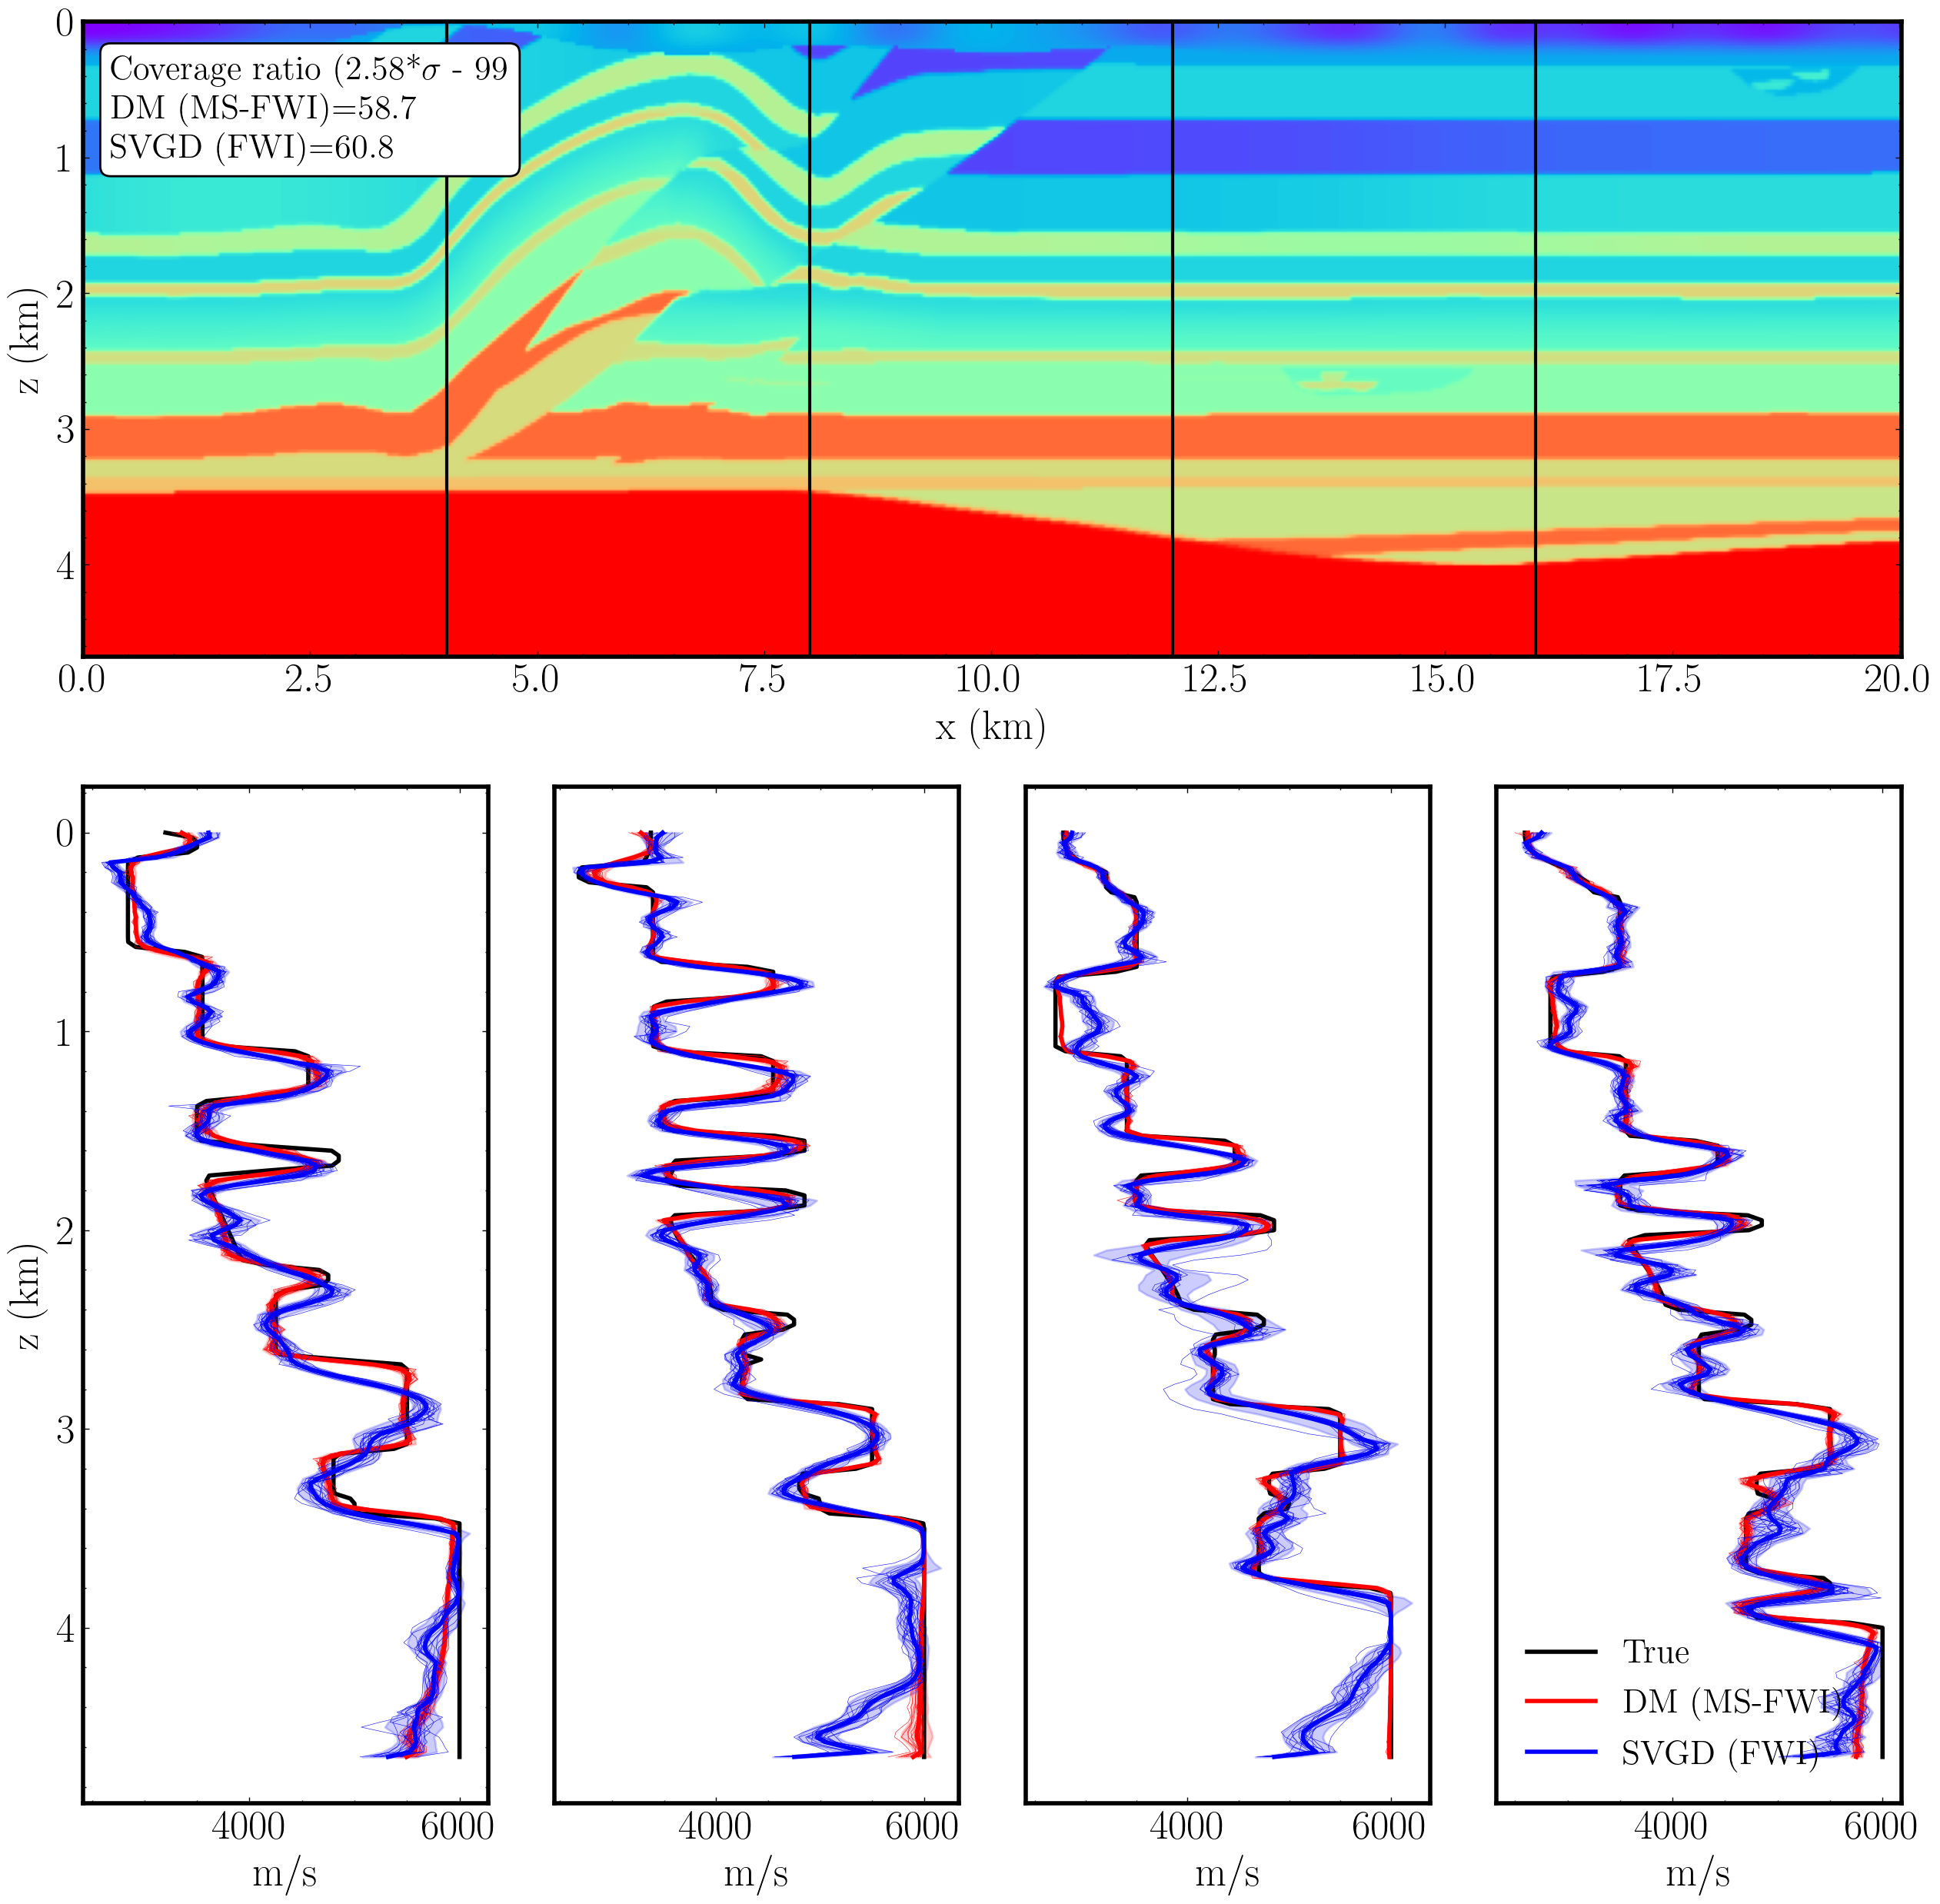

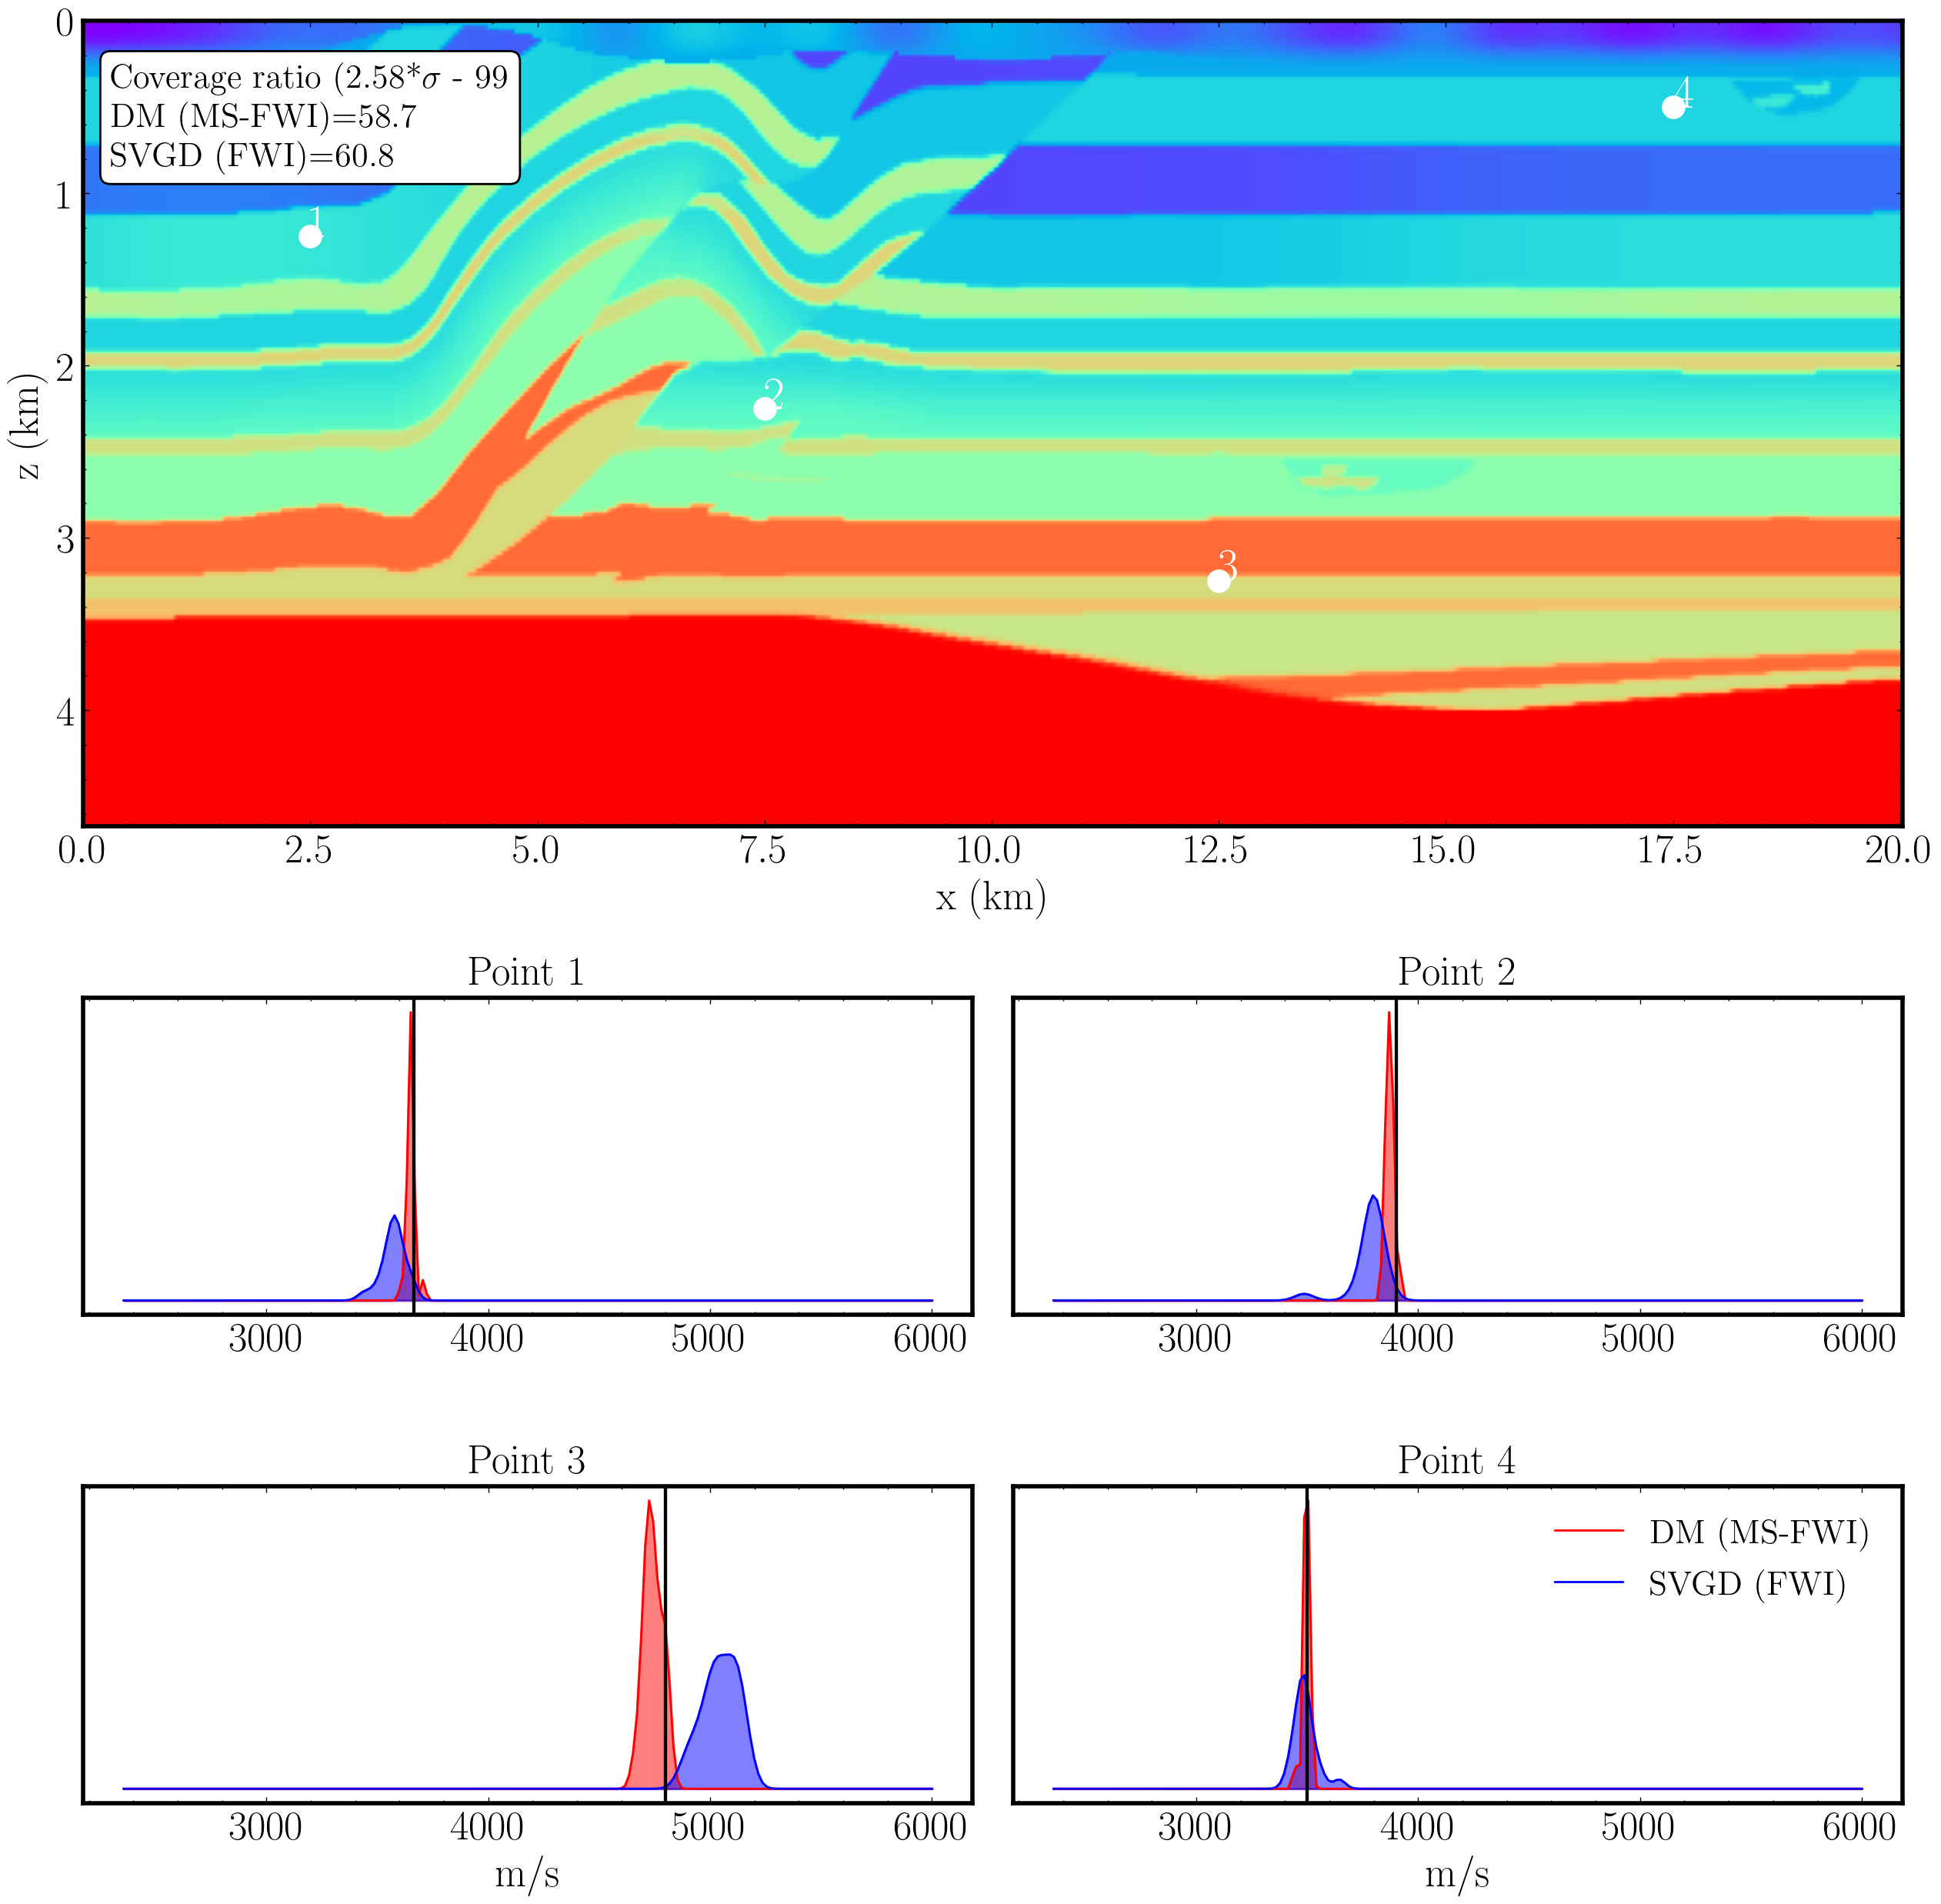

In [9]:
from scipy.ndimage import gaussian_filter
import pickle

vp_true = np.fromfile('../data/velocities/overthrust', np.float32).reshape(801, 801, 187)[400, :, :].T
dx, dz = 25, 25
nz, nx = vp_true.shape
vp_init = gaussian_filter(vp_true, [15, 5])

# Diffusion model with multi-source FWI data

diffusion_path = '../results/DiffusionModel_2D_FWIGuidedSamplingSynthetic_20250817-002635/samples.npy'

vp_diffusion = np.load(diffusion_path)[:, 0]
vp_mean_diffusion = np.load(diffusion_path)[:, 0].mean(0)    
vp_std_diffusion = np.load(diffusion_path)[:, 0].std(0)   

# SVGD with conventional FWI data
svgd_path = "../results/SVGDFWI_2D_Synthetic_20250806-215053/svgd_results_iter_0045.pkl"
with open(svgd_path, "rb") as f:
    svgd_results = pickle.load(f)  # dict with "updates", "updates_mean", "updates_std" 
    
vp_mean_svgd = svgd_results["updates_mean"][-1].reshape(vp_true.shape)
vp_std_svgd = svgd_results["updates_std"][-1].reshape(vp_true.shape)
vp_svgd = svgd_results["updates"][-1].reshape(-1, nz, nx)

show_realizationtraces(
    [vp_diffusion[:,0:], vp_svgd[:,0:]], [vp_mean_diffusion[0:], vp_mean_svgd[0:]], [vp_std_diffusion[0:], vp_std_svgd[0:]], true=vp_true[0:],
    z=np.arange(vp_true[0:].shape[0])*dx/1e3, colors=['r', 'b'],
    extent=[0, vp_true.shape[1] * dx/1e3, vp_true.shape[0] * dz/1e3, 0],
    labels=['DM (MS-FWI)', 'SVGD (FWI)'], vlims=(vp_true.min(), vp_true.max()),
    xlabel='x (km)', ylabel='z (km)', xlabelpdf='m/s',
    figsize=(13, 13)
)

show_1dmarginals(
    [vp_diffusion[:,0:], vp_svgd[:,0:]], [vp_mean_diffusion[0:], vp_mean_svgd[0:]], [vp_std_diffusion[0:], vp_std_svgd[0:]], true=vp_true[0:],
    coords=((100, 50), (300, 90), (500, 130), (700, 20)),
    colors=['r', 'b'], 
    extent=[0, vp_true.shape[1] * dx/1e3, vp_true.shape[0] * dz/1e3, 0],
    labels=['DM (MS-FWI)', 'SVGD (FWI)'], vlims=(vp_true.min(), vp_true.max()),
    xlabel='x (km)', ylabel='z (km)', xlabelpdf='m/s',
    figsize=(13, 13)
)

In [30]:
import numpy as np
import torch
import torch.nn.functional as F

# ---------- MODEL-SPACE METRICS ----------
def model_metrics(vp_pred, vp_true):
    """
    vp_pred, vp_true: torch.Tensor [H,W] or [1,1,H,W] (m/s)
    returns dict of scalars
    """
    if vp_pred.dim() == 4: vp_pred = vp_pred[0,0]
    if vp_true.dim() == 4: vp_true = vp_true[0,0]
    vp_pred = vp_pred.float().cpu()
    vp_true = vp_true.float().cpu()

    vmax = vp_true.max()
    diff = vp_pred - vp_true
    rmse = torch.sqrt(torch.mean(diff**2))
    nrmse = (rmse / (vmax + 1e-12))
    mae = torch.mean(torch.abs(diff))
    rel_l2 = torch.linalg.norm(diff) / (torch.linalg.norm(vp_true) + 1e-12)

    # Pearson correlation
    a = (vp_pred - vp_pred.mean())
    b = (vp_true - vp_true.mean())
    corr = (a*b).sum() / (torch.sqrt((a*a).sum())*torch.sqrt((b*b).sum()) + 1e-12)

    # Gradient/edge error (Sobel)
    kx = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32)/8.0
    ky = kx.t()
    kx = kx.view(1,1,3,3); ky = ky.view(1,1,3,3)
    vp_pred_ = vp_pred.view(1,1,*vp_pred.shape)
    vp_true_ = vp_true.view(1,1,*vp_true.shape)
    gx_p = F.conv2d(vp_pred_, kx, padding=1); gy_p = F.conv2d(vp_pred_, ky, padding=1)
    gx_t = F.conv2d(vp_true_, kx, padding=1); gy_t = F.conv2d(vp_true_, ky, padding=1)
    grad_mae = torch.mean(torch.abs(gx_p-gx_t)) + torch.mean(torch.abs(gy_p-gy_t))

    # Spectral L2 (compare amplitude spectra)
    def amp_spec(x):
        X = torch.fft.rfft2(x)
        return torch.abs(X)
    spec_l2 = torch.linalg.norm(amp_spec(vp_pred) - amp_spec(vp_true)) / \
              (torch.linalg.norm(amp_spec(vp_true)) + 1e-12)

    return {
        "RMSE(m/s)": rmse.item(),
        "NRMSE(: v_max)": nrmse.item(),
        "MAE(m/s)": mae.item(),
        "relL2": rel_l2.item(),
        "Pearson r": corr.item(),
        "Grad-MAE": grad_mae.item(),
        "Spec-relL2": spec_l2.item()
    }

def posterior_coverage(samples, vp_true, alpha=0.1):
    """
    samples: torch.Tensor [S,H,W] of posterior draws (m/s)
    vp_true: torch.Tensor [H,W]
    returns coverage@1-alpha and mean/std maps (as Tensors)
    """
    S, H, W = samples.shape
    q_lo = samples.kthvalue(int(np.floor(alpha/2*S))+1, dim=0).values
    q_hi = samples.kthvalue(int(np.ceil((1-alpha)*S)), dim=0).values
    inside = ((vp_true >= q_lo) & (vp_true <= q_hi)).float()
    coverage = inside.mean().item()
    mean_map = samples.mean(0)
    std_map = samples.std(0, unbiased=True)
    return coverage, mean_map, std_map

# ---------- DATA-SPACE METRICS ----------
def _flatten_traces(d):
    """
    d: torch.Tensor [B, Nr, Nt] or [Nr, Nt] -> [Ntraces, Nt]
    """
    if d.dim() == 3:
        return d.reshape(-1, d.shape[-1]).float().cpu()
    elif d.dim() == 2:
        return d.float().cpu()
    else:
        raise ValueError("Unsupported shape for seismic data")

def data_metrics(d_pred, d_true, dt):
    """
    d_pred, d_true: torch.Tensor with last dim = time
    dt: sampling (s)
    """
    P = _flatten_traces(d_pred)
    T = _flatten_traces(d_true)
    R = T - P

    # L2 and NRMS (%)
    # l2 = torch.linalg.norm(R) / (torch.sqrt(torch.numel(R).float()) + 1e-12)
    l2 = torch.linalg.norm(R) / (R.numel() ** 0.5 + 1e-12)
    rms = lambda x: torch.sqrt(torch.mean(x**2, dim=-1))
    nrms = 100.0 * (2.0 * rms(T - P) / (rms(T) + rms(P) + 1e-12)).mean()

    # Tracewise correlation
    def corr_tr(A, B):
        A = A - A.mean(dim=-1, keepdim=True)
        B = B - B.mean(dim=-1, keepdim=True)
        num = (A*B).sum(dim=-1)
        den = torch.sqrt((A*A).sum(dim=-1)) * torch.sqrt((B*B).sum(dim=-1)) + 1e-12
        return (num/den).mean()
    corr = corr_tr(P, T)

    # Time-shift (via argmax xcorr) -> mean |Δt| in ms
    # FFT-based full correlation per trace
    def mean_abs_timeshift(A, B, dt):
        N = A.shape[-1]
        # zero-mean
        A = A - A.mean(dim=-1, keepdim=True)
        B = B - B.mean(dim=-1, keepdim=True)
        FA = torch.fft.rfft(A, n=2*N)
        FB = torch.fft.rfft(B, n=2*N)
        xcorr = torch.fft.irfft(FA * torch.conj(FB), n=2*N)  # circular corr
        # shift zero-lag to center
        xcorr = torch.roll(xcorr, shifts=N//2, dims=-1)
        lags = torch.argmax(xcorr, dim=-1) - (N//2)
        return (lags.float().abs().mean() * dt * 1e3)  # ms
    mean_dt_ms = mean_abs_timeshift(P, T, dt)

    # Envelope misfit (Hilbert)
    def envelope(x):
        N = x.shape[-1]
        # Hilbert multiplier
        h = torch.zeros(N, dtype=torch.float32)
        if N % 2 == 0:
            h[0] = 1.; h[N//2] = 1.; h[1:N//2] = 2.
        else:
            h[0] = 1.; h[1:(N+1)//2] = 2.
        H = torch.fft.fft(x)
        z = torch.fft.ifft(H * h.to(H.device))
        return torch.abs(z)
    env_err = torch.mean(torch.abs(envelope(T) - envelope(P)))

    # Band-limited spectral error (e.g., 3–12 Hz)
    def band_spectral_relL2(A, B, dt, fmin=3.0, fmax=12.0):
        N = A.shape[-1]
        freqs = torch.fft.rfftfreq(N, dt)
        mask = (freqs >= fmin) & (freqs <= fmax)
        FA = torch.fft.rfft(A, dim=-1)[:, mask]
        FB = torch.fft.rfft(B, dim=-1)[:, mask]
        AE = torch.abs(FA).mean(dim=0)
        BE = torch.abs(FB).mean(dim=0)
        return torch.linalg.norm(AE - BE) / (torch.linalg.norm(BE) + 1e-12)
    spec_err = band_spectral_relL2(P, T, dt)

    # Residual whiteness (lag-1..L autocorr magnitude)
    def residual_whiteness(resid, L=10):
        resid = resid - resid.mean(dim=-1, keepdim=True)
        r = []
        for k in range(1, L+1):
            num = (resid[:, :-k] * resid[:, k:]).mean(dim=-1)
            den = (resid**2).mean(dim=-1) + 1e-12
            r.append((num/den).abs().mean())
        return torch.stack(r).mean()
    whiten = residual_whiteness(R)

    return {
        "L2 per sample": l2.item(),
        "NRMS(%)": nrms.item(),
        "Trace corr": corr.item(),
        "Mean |Δt| (ms)": mean_dt_ms.item(),
        "Envelope L1": env_err.item(),
        "Band spec relL2": spec_err.item(),
        "Residual whiteness": whiten.item()
    }
    
import numpy as np
import torch
import torch.nn.functional as F

# ------- single-sample metrics (2D) -------
@torch.no_grad()
def _model_metrics_single(vp_pred, vp_true):
    """
    vp_pred, vp_true: [H,W] or [1,1,H,W] torch tensors (m/s)
    returns a dict of floats (per-sample)
    """
    if vp_pred.dim() == 4: vp_pred = vp_pred[0,0]
    if vp_true.dim() == 4: vp_true = vp_true[0,0]
    vp_pred = vp_pred.float()
    vp_true = vp_true.float()

    vmax = vp_true.max().clamp_min(1e-12)
    diff = vp_pred - vp_true

    rmse     = torch.sqrt(torch.mean(diff**2))
    nrmse_vm = rmse / vmax                      # normalized by v_max (tiny to report)
    mae      = torch.mean(torch.abs(diff))
    rel_l2   = torch.linalg.vector_norm(diff) / (torch.linalg.vector_norm(vp_true) + 1e-12)

    # global Pearson correlation
    a = (vp_pred - vp_pred.mean())
    b = (vp_true - vp_true.mean())
    corr = (a*b).sum() / (torch.sqrt((a*a).sum())*torch.sqrt((b*b).sum()) + 1e-12)

    # edge/gradient error (Sobel)
    kx = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32, device=vp_pred.device)/8.0
    ky = kx.t()
    kx = kx.view(1,1,3,3); ky = ky.view(1,1,3,3)
    vp_pred_ = vp_pred.view(1,1,*vp_pred.shape)
    vp_true_ = vp_true.view(1,1,*vp_true.shape)
    gx_p = F.conv2d(vp_pred_, kx, padding=1); gy_p = F.conv2d(vp_pred_, ky, padding=1)
    gx_t = F.conv2d(vp_true_, kx, padding=1); gy_t = F.conv2d(vp_true_, ky, padding=1)
    grad_mae = torch.mean(torch.abs(gx_p-gx_t)) + torch.mean(torch.abs(gy_p-gy_t))

    # spectral mismatch (amplitude spectra, relative L2)
    def amp_spec(x): return torch.abs(torch.fft.rfft2(x))
    spec_rel_l2 = torch.linalg.vector_norm(amp_spec(vp_pred) - amp_spec(vp_true)) / \
                  (torch.linalg.vector_norm(amp_spec(vp_true)) + 1e-12)

    return {
        "RMSE (m/s)"     : rmse.item(),
        "NRMSE (v_max)"  : nrmse_vm.item(),
        "MAE (m/s)"      : mae.item(),
        "relL2"          : rel_l2.item(),
        "Pearson r"      : corr.item(),
        "Grad-MAE"       : grad_mae.item(),
        "Spec-relL2"     : spec_rel_l2.item()
    }

# ------- batch summary: mean ± std -------
@torch.no_grad()
def summarize_model_metrics(samples, vp_true, device="cuda", keys=None):
    """
    samples: array-like [S,H,W] or [S,1,1,H,W], torch or numpy
    vp_true: [H,W] torch or numpy
    returns: dict {metric: (mean, std)} over S samples
    """
    # to torch
    if not torch.is_tensor(samples): samples = torch.from_numpy(np.asarray(samples))
    if not torch.is_tensor(vp_true): vp_true = torch.from_numpy(np.asarray(vp_true))
    samples = samples.to(device).float()
    vp_true = vp_true.to(device).float()

    # optional keys filter
    if keys is None:
        keys = ["RMSE (m/s)","NRMSE (v_max)","MAE (m/s)","relL2","Pearson r","Grad-MAE","Spec-relL2"]

    # precompute true on device once
    metrics_per_sample = []
    for s in range(samples.shape[0]):
        vp_s = samples[s]
        m = _model_metrics_single(vp_s, vp_true)
        metrics_per_sample.append(m)

    # stack & summarize
    out = {}
    for k in keys:
        vals = np.array([m[k] for m in metrics_per_sample], dtype=np.float64)
        out[k] = (float(vals.mean()), float(vals.std(ddof=1)) if len(vals)>1 else 0.0)
    return out

# ------- tiny pretty printer (manuscript-friendly) -------
def print_metrics_table(summary_dicts, labels, fmt="{:.1f}±{:.1f}"):
    """
    summary_dicts: list of dicts from summarize_model_metrics (e.g., [svgd_sum, daps_sum])
    labels: list of names for columns (e.g., ["SVGD","DAPS"])
    """
    metrics = list(summary_dicts[0].keys())
    header = ["Metric"] + labels
    row_width = max(len(m) for m in metrics)
    print("{:<{w}}  ".format("Metric", w=row_width), end="")
    for lab in labels: print("{:>14s}  ".format(lab), end="")
    print()
    for m in metrics:
        print("{:<{w}}  ".format(m, w=row_width), end="")
        for sd in summary_dicts:
            mean, std = sd[m]
            print("{:>14s}  ".format(fmt.format(mean, std)), end="")
        print()
        
import numpy as np
import torch
import torch.nn.functional as F

# ---------- build a fixed source permutation once (reused for all samples) ----------
def build_source_batches(total_sources, selected_sources, nx, dx, dz, device, seed=1234):
    """
    Returns a list of source_locations tensors of shape [1, selected_sources, 2].
    The list covers all sources exactly once in a random order (permute then chunk).
    """
    gen = torch.Generator(device=device)
    gen.manual_seed(int(seed))
    perm = torch.randperm(total_sources, generator=gen, device=device)
    y_all = torch.linspace(0, (nx - 1) * dx, total_sources, device=device)[perm]

    batches = []
    for i in range(0, total_sources, selected_sources):
        y_sel = y_all[i:i+selected_sources]
        src = torch.zeros(1, y_sel.numel(), 2, device=device)
        src[0, :, 0] = dx          # z coordinate (depth of sources)
        src[0, :, 1] = y_sel       # x coordinate(s)
        # normalize to grid index units expected by your propagator
        src[:, :, 0] /= dz         # z index
        src[:, :, 1] /= dx         # x index
        batches.append(src)
    return batches

# ---------- flatten gathers to [Ntraces, Nt] ----------
def _flatten_traces(d):
    d = d.detach()
    if d.dim() == 4:      # e.g., [B, S, Nr, Nt]
        B, S, Nr, Nt = d.shape
        return d.reshape(B*S*Nr, Nt).float().cpu()
    if d.dim() == 3:      # e.g., [S, Nr, Nt] or [B, Nr, Nt]
        return d.reshape(-1, d.shape[-1]).float().cpu()
    if d.dim() == 2:      # [Nr, Nt]
        return d.float().cpu()
    raise ValueError(f"Unsupported seismic tensor shape: {tuple(d.shape)}")

# ---------- per-dataset data metrics ----------
@torch.no_grad()
def data_metrics_single(d_pred, d_true, dt):
    """
    d_pred, d_true: tensors whose last dim is time. Any leading dims are traces/batches.
    Returns a dict of scalar metrics for this dataset.
    """
    P = _flatten_traces(d_pred)
    T = _flatten_traces(d_true)
    R = T - P

    # L2 per sample (normalized by sqrt(numel))
    l2 = torch.linalg.vector_norm(R) / (R.numel() ** 0.5 + 1e-12)

    # NRMS (%) = mean over traces
    rms = lambda x: torch.sqrt(torch.mean(x**2, dim=-1))
    nrms = 100.0 * (2.0 * rms(R) / (rms(T) + rms(P) + 1e-12)).mean()

    # Tracewise correlation (mean over traces)
    def corr_tr(A, B):
        A = A - A.mean(dim=-1, keepdim=True)
        B = B - B.mean(dim=-1, keepdim=True)
        num = (A * B).sum(dim=-1)
        den = torch.sqrt((A*A).sum(dim=-1)) * torch.sqrt((B*B).sum(dim=-1)) + 1e-12
        return (num / den).mean()
    corr = corr_tr(P, T)

    # Mean |Δt| via xcorr argmax (ms)
    def mean_abs_timeshift(A, B, dt):
        N = A.shape[-1]
        A = A - A.mean(dim=-1, keepdim=True)
        B = B - B.mean(dim=-1, keepdim=True)
        FA = torch.fft.rfft(A, n=2*N)
        FB = torch.fft.rfft(B, n=2*N)
        xcorr = torch.fft.irfft(FA * torch.conj(FB), n=2*N)
        xcorr = torch.roll(xcorr, shifts=N//2, dims=-1)
        lags = torch.argmax(xcorr, dim=-1) - (N//2)
        return (lags.float().abs().mean() * dt * 1e3)
    mean_dt_ms = mean_abs_timeshift(P, T, dt)

    # Envelope misfit (Hilbert amplitude)
    def envelope(x):
        N = x.shape[-1]
        h = torch.zeros(N, dtype=torch.float32)
        if N % 2 == 0:
            h[0] = 1.; h[N//2] = 1.; h[1:N//2] = 2.
        else:
            h[0] = 1.; h[1:(N+1)//2] = 2.
        H = torch.fft.fft(x)
        z = torch.fft.ifft(H * h.to(H.device))
        return torch.abs(z)
    env_l1 = torch.mean(torch.abs(envelope(T) - envelope(P)))

    # Band-limited spectral error (relative L2 of average amplitude spectrum)
    def band_spectral_relL2(A, B, dt, fmin=3.0, fmax=12.0):
        N = A.shape[-1]
        freqs = torch.fft.rfftfreq(N, dt)
        mask = (freqs >= fmin) & (freqs <= fmax)
        FA = torch.fft.rfft(A, dim=-1)[:, mask]
        FB = torch.fft.rfft(B, dim=-1)[:, mask]
        AE = torch.abs(FA).mean(dim=0)
        BE = torch.abs(FB).mean(dim=0)
        return torch.linalg.vector_norm(AE - BE) / (torch.linalg.vector_norm(BE) + 1e-12)
    spec_rel_l2 = band_spectral_relL2(P, T, dt)

    # Residual whiteness (mean |autocorr| over lags 1..L)
    def residual_whiteness(resid, L=10):
        resid = resid - resid.mean(dim=-1, keepdim=True)
        r = []
        for k in range(1, L+1):
            num = (resid[:, :-k] * resid[:, k:]).mean(dim=-1)
            den = (resid**2).mean(dim=-1) + 1e-12
            r.append((num/den).abs().mean())
        return torch.stack(r).mean()
    whiten = residual_whiteness(R)

    return {
        "L2/sample"       : l2.item(),
        "NRMS(%)"         : nrms.item(),
        "Trace corr"      : corr.item(),
        "Mean |Δt| (ms)"  : mean_dt_ms.item(),
        "Envelope L1"     : env_l1.item(),
        "Band spec relL2" : spec_rel_l2.item(),
        "Residual white"  : whiten.item()
    }

In [16]:
# ---- Posterior mean models (your current comparison) ----
vp_mean_svgd_t = torch.from_numpy(vp_mean_svgd)
vp_mean_diff_t = torch.from_numpy(vp_mean_diffusion)
vp_true_t      = torch.from_numpy(vp_true)

print("Mean SVGD:", model_metrics(vp_mean_svgd_t, vp_true_t))
print("Mean DAPS:", model_metrics(vp_mean_diff_t, vp_true_t))

Mean SVGD: {'RMSE(m/s)': 277.34136962890625, 'NRMSE(: v_max)': 0.046223562210798264, 'MAE(m/s)': 197.50474548339844, 'relL2': 0.060485467314720154, 'Pearson r': 0.9700176119804382, 'Grad-MAE': 112.08226776123047, 'Spec-relL2': 0.038476165384054184}
Mean DAPS: {'RMSE(m/s)': 144.91639709472656, 'NRMSE(: v_max)': 0.024152733385562897, 'MAE(m/s)': 88.5904769897461, 'relL2': 0.03160536661744118, 'Pearson r': 0.9919900894165039, 'Grad-MAE': 47.11810302734375, 'Spec-relL2': 0.019839193671941757}


In [18]:
# ---- Posterior calibration (coverage at 90%) ----
# stack samples as [S,H,W]
samples_daps = torch.from_numpy(np.stack(vp_diffusion[:50], axis=0))
cov90, m_map, s_map = posterior_coverage(samples_daps, torch.from_numpy(vp_true), alpha=0.1)
print(f"Coverage@90% (DAPS): {cov90:.3f}")

samples_svgd = torch.from_numpy(np.stack(vp_svgd[:50], axis=0))
cov90, m_map, s_map = posterior_coverage(samples_svgd, torch.from_numpy(vp_true), alpha=0.1)
print(f"Coverage@90% (SVGD): {cov90:.3f}")

Coverage@90% (DAPS): 0.355
Coverage@90% (SVGD): 0.336


In [21]:
# vp_diffusion: [S,H,W], vp_svgd: [S,H,W], vp_true: [H,W]
S = 20
daps_sum = summarize_model_metrics(vp_diffusion[:S], vp_true, device="cuda")
svgd_sum = summarize_model_metrics(vp_svgd[:S],      vp_true, device="cuda")

print_metrics_table([svgd_sum, daps_sum], labels=["SVGD","DAPS"], fmt="{:.3f}±{:.3f}")

Metric                   SVGD            DAPS  
RMSE (m/s)     289.828±15.899   148.792±2.008  
NRMSE (v_max)     0.048±0.003     0.025±0.000  
MAE (m/s)      206.870±12.814    91.914±1.244  
relL2             0.063±0.003     0.032±0.000  
Pearson r         0.966±0.005     0.991±0.000  
Grad-MAE        126.521±5.643    52.999±0.349  
Spec-relL2        0.039±0.001     0.020±0.000  


In [33]:
from collections import defaultdict
import numpy as np
import torch

# ---- Data-space metrics (mean ± std over samples) ----
seed = 1234
device = "cuda"

# 0) Simulate ground-truth data ONCE (fixed seed & settings)
dtrue = forward_propagator(torch.from_numpy(vp_true).to(device).float(),
                           seed=seed, multi_source=True, freq=5,
                           nt=2000, dt=0.004, dz=dz, dx=dx,
                           total_sources=64, selected_sources=64).detach().cpu()

# 1) Accumulators
S = min(20, len(vp_diffusion), len(vp_svgd))
metrics_svgd = defaultdict(list)
metrics_daps = defaultdict(list)

# 2) Loop over samples and collect metrics
for i in range(S):
    ddap  = forward_propagator(torch.from_numpy(vp_diffusion[i]).to(device).float(),
                               seed=seed, multi_source=True, freq=5,
                               nt=2000, dt=0.004, dz=dz, dx=dx,
                               total_sources=64, selected_sources=64).detach().cpu()

    dsvgd = forward_propagator(torch.from_numpy(vp_svgd[i]).to(device).float(),
                               seed=seed, multi_source=True, freq=5,
                               nt=2000, dt=0.004, dz=dz, dx=dx,
                               total_sources=64, selected_sources=64).detach().cpu()

    m_svgd = data_metrics(dsvgd, dtrue, dt=0.004)
    m_daps = data_metrics(ddap , dtrue, dt=0.004)

    for k, v in m_svgd.items():
        metrics_svgd[k].append(float(v))
    for k, v in m_daps.items():
        metrics_daps[k].append(float(v))

# 3) Summarize as mean ± std and print a compact table
keys = list(metrics_svgd.keys())  # assumes same keys from both
colw = max(len(k) for k in keys)
print("{:<{w}}  {:>16s}  {:>16s}".format("Metric", "SVGD (mean±std)", "DAPS (mean±std)", w=colw))
for k in keys:
    s = np.asarray(metrics_svgd[k], dtype=np.float64)
    d = np.asarray(metrics_daps[k], dtype=np.float64)
    print("{:<{w}}  {:>16s}  {:>16s}".format(
        k,
        f"{s.mean():.4f}±{s.std(ddof=1):.4f}" if s.size>1 else f"{s.mean():.4f}±0.0000",
        f"{d.mean():.4f}±{d.std(ddof=1):.4f}" if d.size>1 else f"{d.mean():.4f}±0.0000",
        w=colw
    ))


Metric               SVGD (mean±std)   DAPS (mean±std)
L2 per sample          1.0767±0.1114     0.7576±0.1161
NRMS(%)               12.3919±1.2803     8.6167±1.2628
Trace corr             0.9915±0.0020     0.9958±0.0013
Mean |Δt| (ms)         0.0137±0.0416     0.1408±0.2356
Envelope L1            0.7199±0.0678     0.3826±0.0108
Band spec relL2        0.0211±0.0031     0.0138±0.0020
Residual whiteness     0.4980±0.0024     0.5063±0.0017


In [ ]:
# Compute min and max along spatial dimensions only (keep sample and channel dimensions)
m_min = 1500
m_max = 4500

device = torch.device('cuda')

source_amplitudes = torch.from_numpy(
np.load('/home/taufikmh/KAUST/fall_2024/guidedifwi-dev/data/source_amplitude.npy')
).float().to(device)

obs_data = torch.from_numpy(
np.load('/home/taufikmh/KAUST/fall_2024/guidedifwi-dev/data/observed_data.npy')
).float().to(device)

# Load initial velocity model
vp_init = torch.from_numpy(
np.load('/home/taufikmh/KAUST/fall_2024/guidedifwi-dev/data/initial_velocity.npy')
).float().to(device)

# Load velocity model mask
vp_mask = torch.from_numpy(
np.load('/home/taufikmh/KAUST/fall_2024/guidedifwi-dev/data/velocity_mask.npy')
).float().to(device)

# Load receiver mask
receiver_mask = torch.from_numpy(
np.load('/home/taufikmh/KAUST/fall_2024/guidedifwi-dev/data/receiver_mask.npy')
).bool().to(device)

source_locations = torch.from_numpy(
    np.load('/home/taufikmh/KAUST/fall_2024/guidedifwi-dev/data/source_locations.npy').reshape(-1, 1, 2)
).float().to(device)

receiver_locations = torch.from_numpy(
    np.load('/home/taufikmh/KAUST/fall_2024/guidedifwi-dev/data/receiver_locations.npy').reshape(source_locations.shape[0], -1, 2)
).float().to(device)

# Set parameters
multi_source = False

obs_scaler = torch.max(torch.abs(obs_data))

dx = 25
dz = 25
nz, nx = vp_init.shape
freq = 6
dt = 0.002
nt = 3525
num_dims = 2
num_batches = 8 # 4 worked on A100
num_shots = 1 if multi_source else source_locations.shape[0]
num_sources_per_shot = source_locations.shape[0] if multi_source else 1
num_receivers_per_shot = receiver_locations.shape[1]

diffusion_path_field = '../results/DiffusionModel_2D_FWIGuidedSamplingField_20250807-173601/samples.npy'
svgd_path_field = '../results/SVGDFWI_2D_Field_20250810-231512/svgd_results_iter_0199.pkl'

vp_diffusion_field = np.load(diffusion_path_field)[:, 0]
vp_mean_diffusion_field = np.load(diffusion_path_field)[:, 0].mean(0)    
vp_std_diffusion_field = np.load(diffusion_path_field)[:, 0].std(0)   

# SVGD with conventional FWI data
with open(svgd_path_field, "rb") as f:
    svgd_results_field = pickle.load(f)  # dict with "updates", "updates_mean", "updates_std" 
    
vp_mean_svgd_field = svgd_results_field["updates_mean"][-1].reshape(vp_init.shape)
vp_std_svgd_field = svgd_results_field["updates_std"][-1].reshape(vp_init.shape)
vp_svgd_field = svgd_results_field["updates"][-1].reshape(-1, nz, nx)

In [40]:
from collections import defaultdict
import numpy as np
import torch

# ---- Data-space metrics (mean ± std over samples) ----
seed = 1234
device = "cuda"

# 0) Simulate ground-truth data ONCE (fixed seed & settings)
dtrue = obs_data

# 1) Accumulators
S = min(20, len(vp_diffusion_field), len(vp_svgd_field))
metrics_svgd = defaultdict(list)
metrics_daps = defaultdict(list)

# 2) Loop over samples and collect metrics
for i in range(S):

    ddap = deepwave.scalar(
        torch.from_numpy(vp_diffusion_field[i]).to(device).float(), 
        dt=dt, 
        grid_spacing=[dz, dx],
        source_amplitudes=source_amplitudes,
        source_locations=source_locations,
        receiver_locations=receiver_locations,
        accuracy=8,
        pml_freq=freq,
        pml_width=[0, 10, 10, 10],
        max_vel=4500
    )[-1]

    dsvgd = deepwave.scalar(
        torch.from_numpy(vp_svgd_field[i]).to(device).float(), 
        dt=dt, 
        grid_spacing=[dz, dx],
        source_amplitudes=source_amplitudes,
        source_locations=source_locations,
        receiver_locations=receiver_locations,
        accuracy=8,
        pml_freq=freq,
        pml_width=[0, 10, 10, 10],
        max_vel=4500
    )[-1]

    m_svgd = data_metrics(dsvgd, dtrue, dt=dt)
    m_daps = data_metrics(ddap , dtrue, dt=dt)

    for k, v in m_svgd.items():
        metrics_svgd[k].append(float(v))
    for k, v in m_daps.items():
        metrics_daps[k].append(float(v))

# 3) Summarize as mean ± std and print a compact table
keys = list(metrics_svgd.keys())  # assumes same keys from both
colw = max(len(k) for k in keys)
print("{:<{w}}  {:>16s}  {:>16s}".format("Metric", "SVGD (mean±std)", "DAPS (mean±std)", w=colw))
for k in keys:
    s = np.asarray(metrics_svgd[k], dtype=np.float64)
    d = np.asarray(metrics_daps[k], dtype=np.float64)
    print("{:<{w}}  {:>16s}  {:>16s}".format(
        k,
        f"{s.mean():.4f}±{s.std(ddof=1):.4f}" if s.size>1 else f"{s.mean():.4f}±0.0000",
        f"{d.mean():.4f}±{d.std(ddof=1):.4f}" if d.size>1 else f"{d.mean():.4f}±0.0000",
        w=colw
    ))


Metric               SVGD (mean±std)   DAPS (mean±std)
L2 per sample       4221.9248±37.9992  4175.4021±14.1335
NRMS(%)              199.9965±0.0002   199.9958±0.0000
Trace corr             0.5394±0.0251     0.5563±0.0027
Mean |Δt| (ms)        72.7471±9.0025    62.9806±0.7221
Envelope L1         2270.3421±61.9298  1985.9125±4.7164
Band spec relL2     107206.8332±1119.4925  103329.3668±282.8647
Residual whiteness     0.8538±0.0004     0.8549±0.0001
